<a href="https://colab.research.google.com/github/zzprogram/APM1111/blob/main/FA11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


DESCRIPTIVE STATISTICS


group,Mean,SD,N
<fct>,<dbl>,<dbl>,<int>
ctrl,5.032,0.5830914,10
trt1,4.661,0.7936757,10
trt2,5.526,0.4425733,10



NORMALITY TEST - SHAPIRO-WILK


df$group: ctrl
      W p_value
W 0.957   0.747
------------------------------------------------------------ 
df$group: trt1
     W p_value
W 0.93   0.452
------------------------------------------------------------ 
df$group: trt2
      W p_value
W 0.941   0.564


TEST FOR EQUALITY OF VARIANCES - LEVENE'S


...


EFFECT SIZE (ETA SQUARED)


,eta.sq,eta.sq.part
group,0.2641483,0.2641483



POST HOC TEST


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = weight ~ group, data = df)

$group
            diff        lwr       upr     p adj
trt1-ctrl -0.371 -1.0622161 0.3202161 0.3908711
trt2-ctrl  0.494 -0.1972161 1.1852161 0.1979960
trt2-trt1  0.865  0.1737839 1.5562161 0.0120064



BOXPLOT


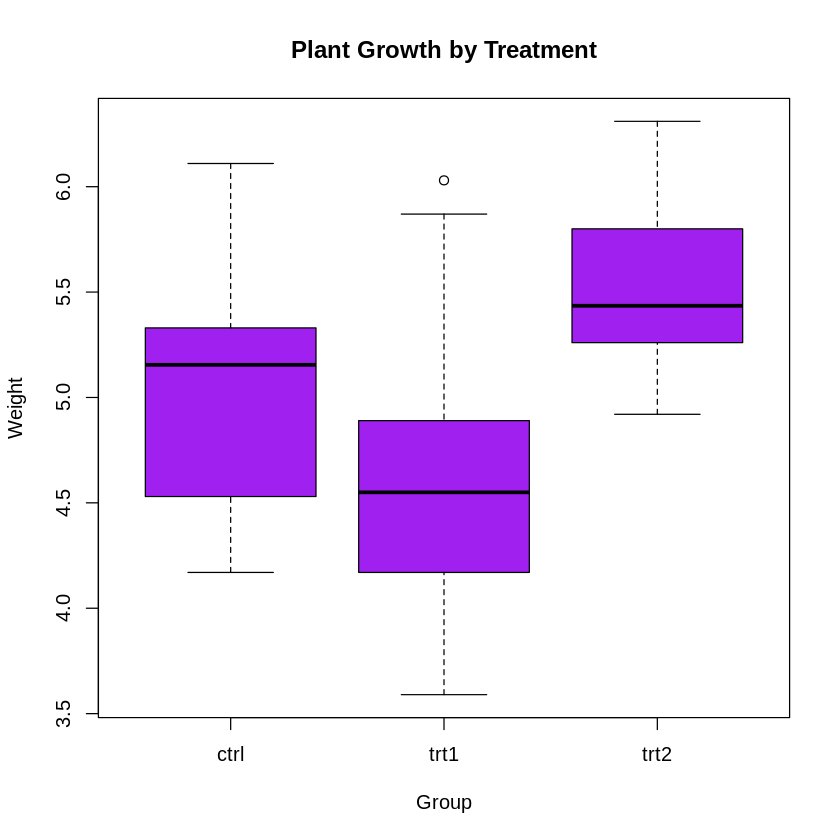

In [21]:
#dataset
data("PlantGrowth")
df <- PlantGrowth

#descriptive
cat("\nDESCRIPTIVE STATISTICS\n")
library(dplyr)

df %>%
  group_by(group) %>%
  summarise(
    Mean = mean(weight),
    SD = sd(weight),
    N = n()
  )

#normal test
cat("\nNORMALITY TEST - SHAPIRO-WILK\n")

by(df$weight, df$group, function(x) {
  result <- shapiro.test(x)
  data.frame(W = round(result$statistic, 3),
    p_value = round(result$p.value, 3)
  )
})

#variance
cat("\nTEST FOR EQUALITY OF VARIANCES - LEVENE'S\n")
library(car)

leveneTest(weight ~ group, data = df)

#one way anova
cat("\nANOVA RESULT\n")

anova_model <- aov(weight ~ group, data = df)
summary(anova_model)

#size
cat("\nEFFECT SIZE (ETA SQUARED)\n")
library(lsr)

etaSquared(anova_model)

#post hoc test
cat("\nPOST HOC TEST\n")

TukeyHSD(anova_model)

#boxplot
cat("\nBOXPLOT\n")

boxplot(weight ~ group, data = df,
        col = "purple",
        main = "Plant Growth by Treatment",
        xlab = "Group",
        ylab = "Weight")